# Figure 1: Deconvolution Model

**Goal:**

Create the figures that will be used to convey the first result: Chromatin deconvolution increases temporal resolution.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [104]:
from src.Figure1_deconvolution import Figure1Deconvolution
fig1 = Figure1Deconvolution()

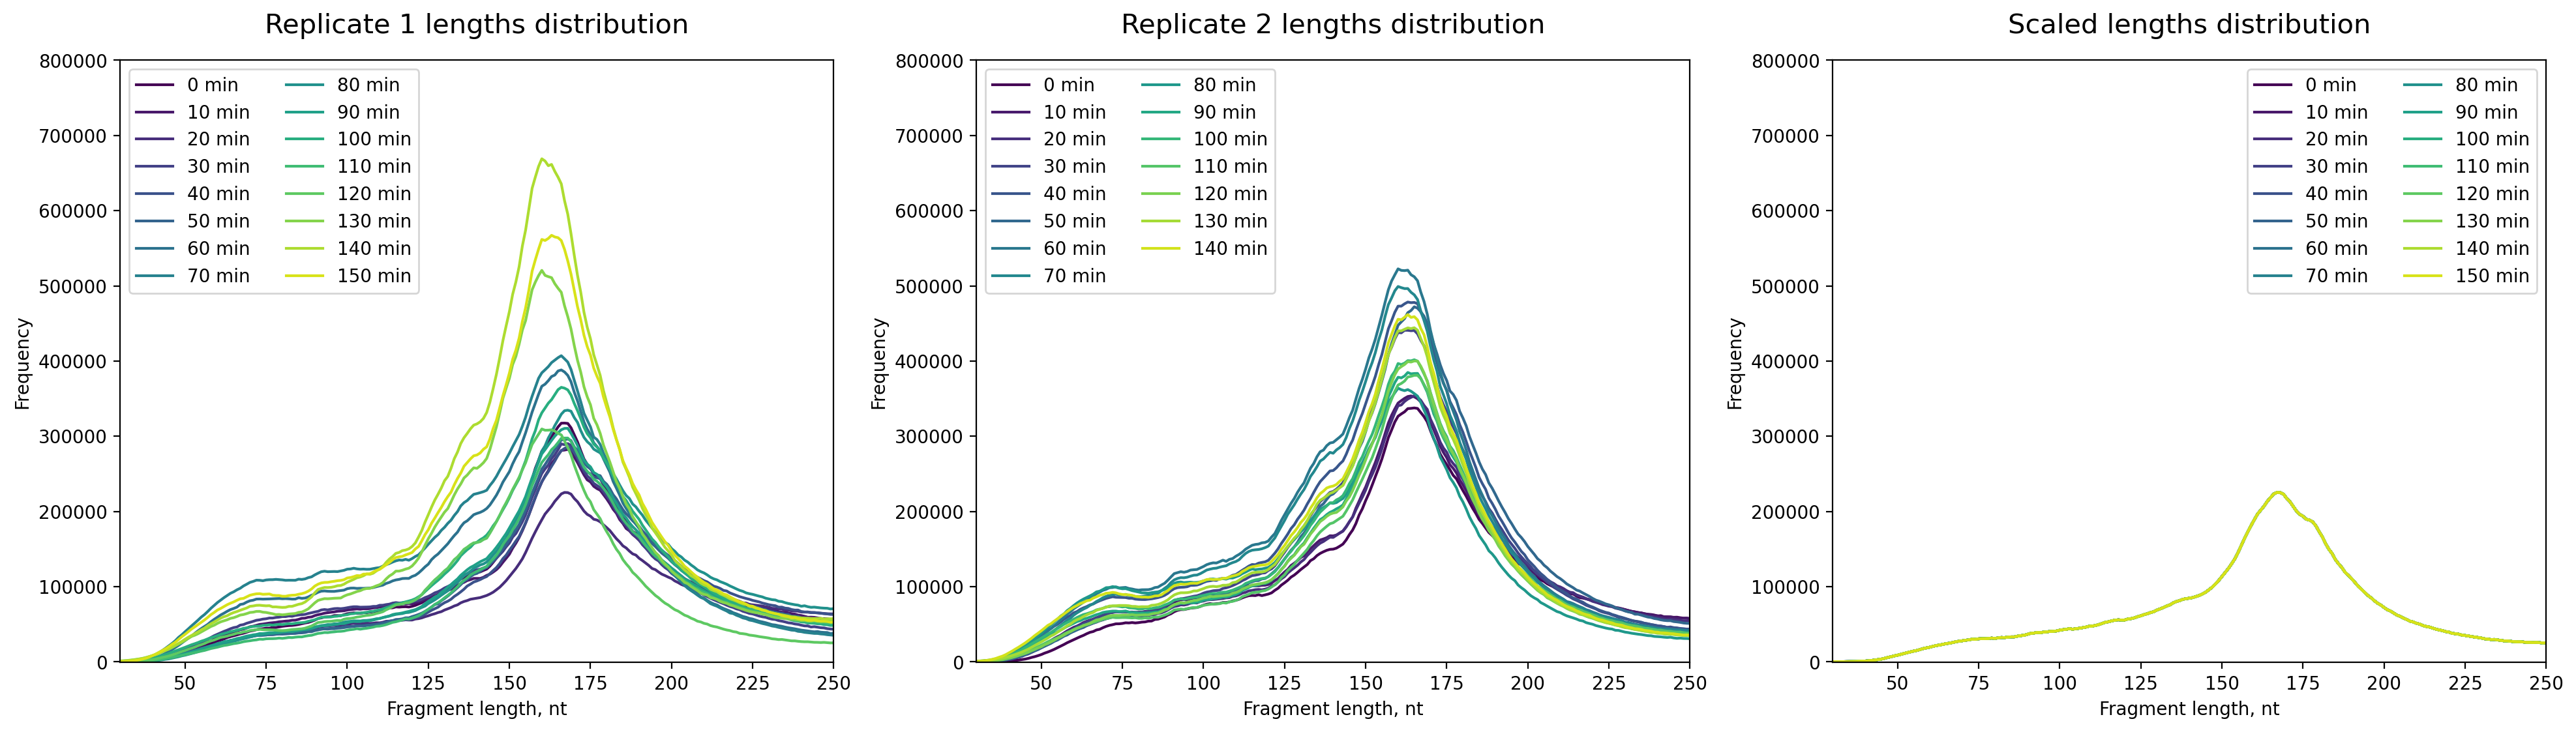

In [206]:
from src.chromatin_metrics import plot_len_counts

plt.figure(figsize=(24, 6))
plt.subplot(1, 3, 1)
rep1_len_dist = pd.read_csv('output/mnase/rep1_len_counts_fix.csv')
plot_len_counts(rep1_len_dist, show_len_cutoffs=False, title="Replicate 1 lengths distribution")
plt.ylim(-1000, 800000)

plt.subplot(1, 3, 2)
rep2_len_dist = pd.read_csv('output/mnase/rep2_len_counts_fix.csv')
plot_len_counts(rep2_len_dist, show_len_cutoffs=False, title="Replicate 2 lengths distribution")
plt.ylim(-1000, 800000)

plt.subplot(1, 3, 3)
len_scaling = pd.read_csv('datasets/computed_mnase/combined_len_scaling.csv')
len_scaling = len_scaling.set_index('length')

rep1_cols = len_scaling.columns[len_scaling.columns.astype(str).str.endswith('_replicate1')]
rep2_cols = len_scaling.columns[len_scaling.columns.astype(str).str.endswith('_replicate2')]

rep1_scaling = len_scaling[rep1_cols]
rep2_scaling = len_scaling[rep2_cols]

scaled_rep2_lens = rep2_len_dist.copy()
scaled_rep2_lens.loc[:] = rep2_len_dist.values * rep2_scaling.values

scaled_rep1_lens = rep1_len_dist.copy()
scaled_rep1_lens.loc[:] = rep1_len_dist.values * rep1_scaling.values

plot_len_counts(scaled_rep1_lens, show_len_cutoffs=False, title="Scaled lengths distribution")
plt.ylim(-1000, 800000)

save_figure_for_paper("output/figures/Chromatin_Deconvolution/Lengths_Distribution.png")


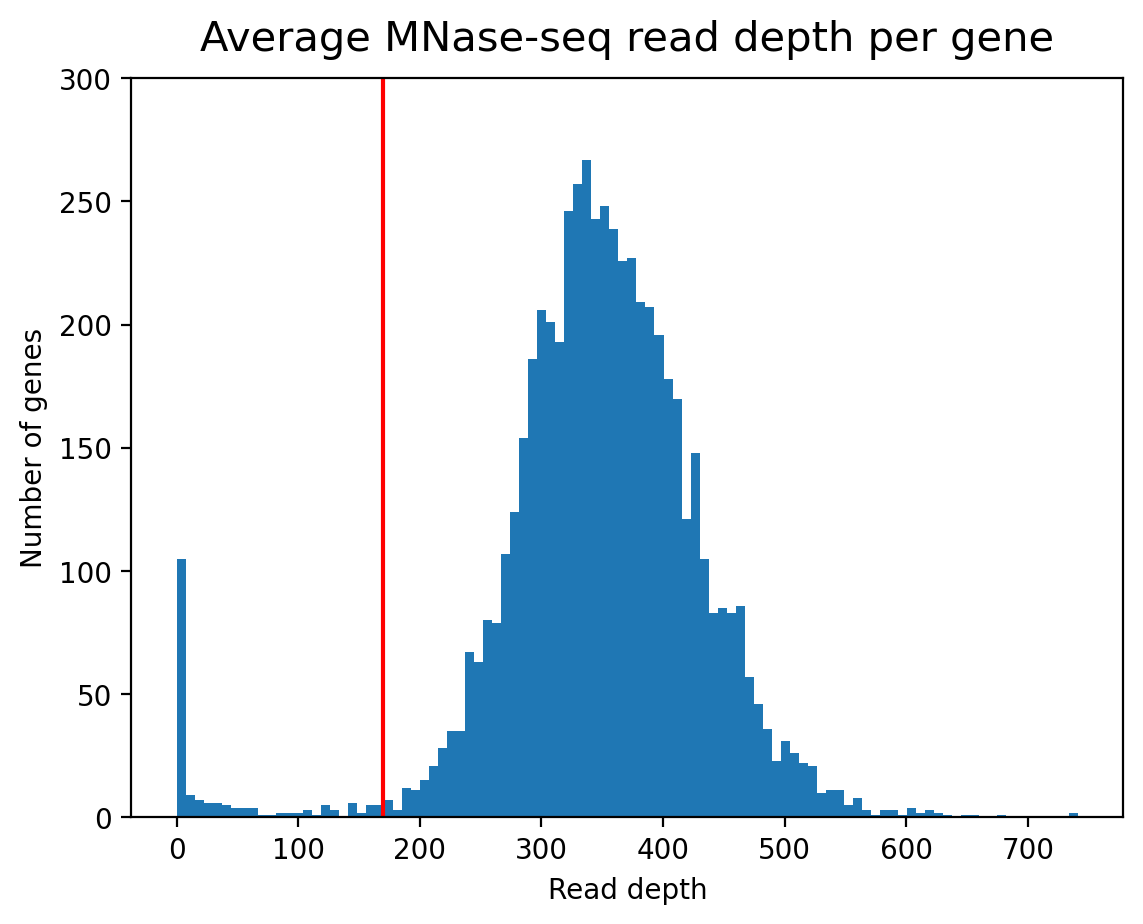

In [156]:
from src.figure_configs import FiguresConfig
gene_read_depth_coverage = pd.read_csv('datasets/computed_mnase/combined_mnase_seq_coverage.csv').set_index('orf_name')

avg_depth = (gene_read_depth_coverage.depth_rep1+gene_read_depth_coverage.depth_rep2)/2
plt.hist(avg_depth, bins=100)
plt.ylim(0, 300)
plt.title("Average MNase-seq read depth per gene", 
          fontsize=FiguresConfig.FIG_SUPTITLE_FONTSIZE, pad=10)
plt.axvline(170, c='red')
plt.xlabel("Read depth")
plt.ylabel("Number of genes")
save_figure_for_paper("output/figures/Methods/Average_Read_Depth.png")


In [105]:
fig1.print_posteriors()

$\mu0$	&	-26.790	&	(-27.055,-26.474)	&&	-20.151	&	(-20.346,-19.945) \\
$\delta$	&	8.181	&	(7.461,8.819)	&&	10.895	&	(10.437,11.355) \\
$\sigma_0$	&	10.989	&	(10.873,11.105)	&&	10.631	&	(10.513,10.747) \\
$\sigma_v$	&	0.142	&	(0.139,0.145)	&&	0.130	&	(0.127,0.133) \\
$\lambda$	&	68.191	&	(67.711,68.691)	&&	60.209	&	(59.870,60.555) \\
$\gamma_1$	&	0.004	&	(0.002,0.008)	&&	0.002	&	(0.001,0.003) \\
$\gamma_2$	&	0.255	&	(0.252,0.258)	&&	0.284	&	(0.282,0.286) \\
$\mu_{\alpha1}$	&	7.733	&	(7.732,7.734)	&&	7.585	&	(7.584,7.586) \\
$\sigma_{\alpha1}$	&	0.001	&	(0.001,0.002)	&&	0.001	&	(0.001,0.002) \\
$\mu_{\alpha2}$	&	1.017	&	(1.001,1.033)	&&	1.010	&	(1.002,1.018) \\
$\sigma_{\alpha2}$	&	0.031	&	(0.016,0.059)	&&	0.016	&	(0.008,0.030) \\
$\mu_t$	&	-2.473	&	(-2.507,-2.438)	&&	-2.483	&	(-2.522,-2.445) \\
$\sigma_t$	&	0.067	&	(0.035,0.129)	&&	0.075	&	(0.039,0.145) \\
halted	&	0.225	&	(0.220,0.229)	&&	0.291	&	(0.286,0.295) \\


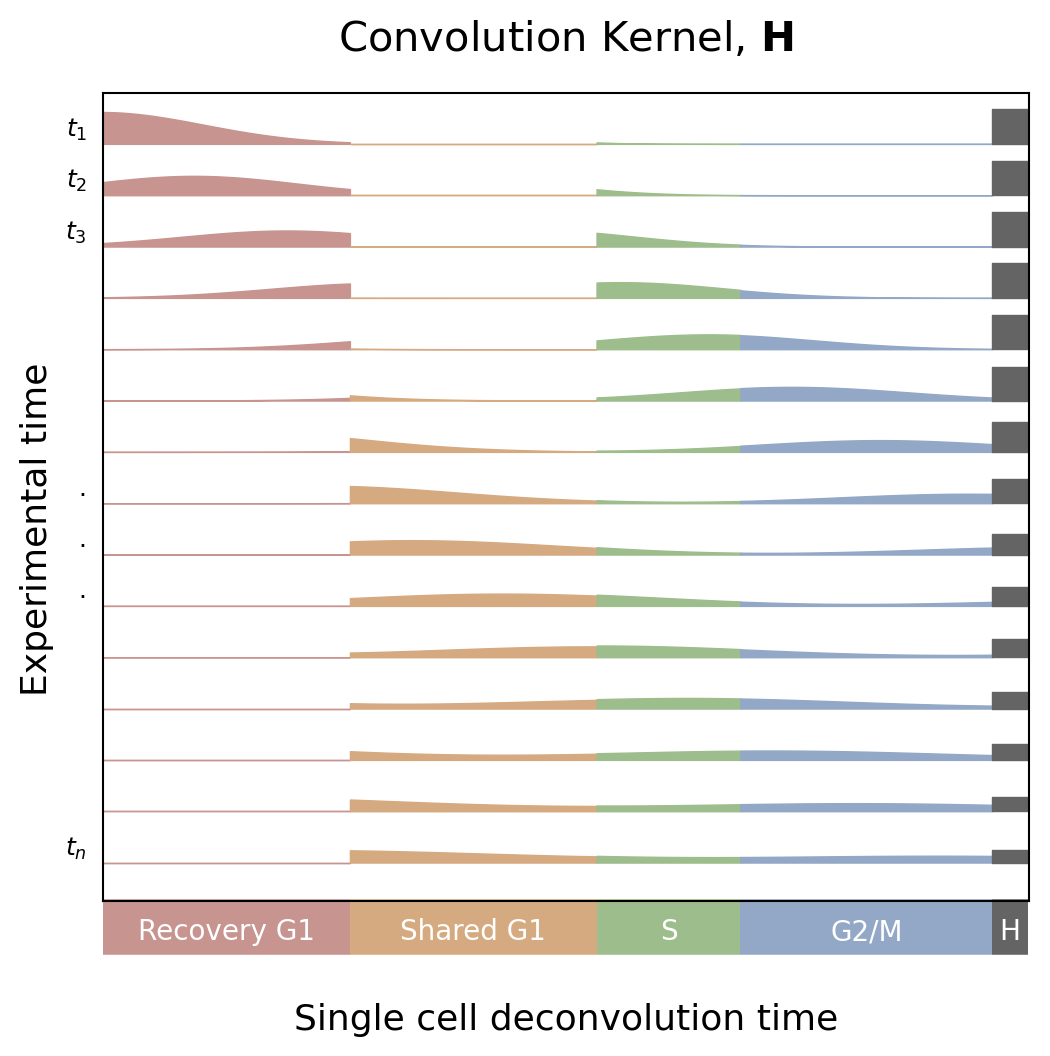

In [106]:
from src.figure_configs import save_figure_for_paper

fig1.plot_H_fill_betweens()
save_figure_for_paper("output/figures/Chromatin_Deconvolution/Deconvolution_H_fill.png")

In [107]:
fig1.compute_deconvolution('CLN2')

Loading MNase reads for YPL256C/CLN2...Loading chromosome reads: 16
Done.
Applying chromatin copy number correction
Loading MNase reads for YPL256C/CLN2...Loading chromosome reads: 16
Done.
Applying chromatin copy number correction
Deconvolving combined model with gamma=0.006
Deconvolving bin size: 11x11
of G shape: (31, 2093)
Deconvolving with gamma=0.006
0/2093 - 00:00:00.102
100/2093 - 00:00:07.024
200/2093 - 00:00:13.993
300/2093 - 00:00:20.738
400/2093 - 00:00:26.977
500/2093 - 00:00:33.030
600/2093 - 00:00:39.028
700/2093 - 00:00:45.014
800/2093 - 00:00:51.014
900/2093 - 00:00:57.151
1000/2093 - 00:01:03.205
1100/2093 - 00:01:09.270
1200/2093 - 00:01:15.410
1300/2093 - 00:01:21.604
1400/2093 - 00:01:27.911
1500/2093 - 00:01:34.343
1600/2093 - 00:01:40.938
1700/2093 - 00:01:47.265
1800/2093 - 00:01:53.512
1900/2093 - 00:01:59.544
2000/2093 - 00:02:05.597
Deconvolved in : 00:02:12.109
The fitting norm is 15.82, the smoothing norm is: 7.16


In [127]:
fig1.combined_model.save_deconvolved_outputs('/Users/trung/Desktop/', 0)

Saved to /Users/trung/Desktop//0_g1_YPL256C_CLN2.npy...
Saved to /Users/trung/Desktop//0_g2_YPL256C_CLN2.npy...
Saved to /Users/trung/Desktop//0_g1_correction_YPL256C_CLN2.csv...
Saved to /Users/trung/Desktop//0_g2_correction_YPL256C_CLN2.csv...
Saved to /Users/trung/Desktop//0_f_YPL256C_CLN2.npy...
Saved to /Users/trung/Desktop//0_ptr_YPL256C_CLN2.npy...
Saved to /Users/trung/Desktop//0_meta_YPL256C_CLN2.csv...


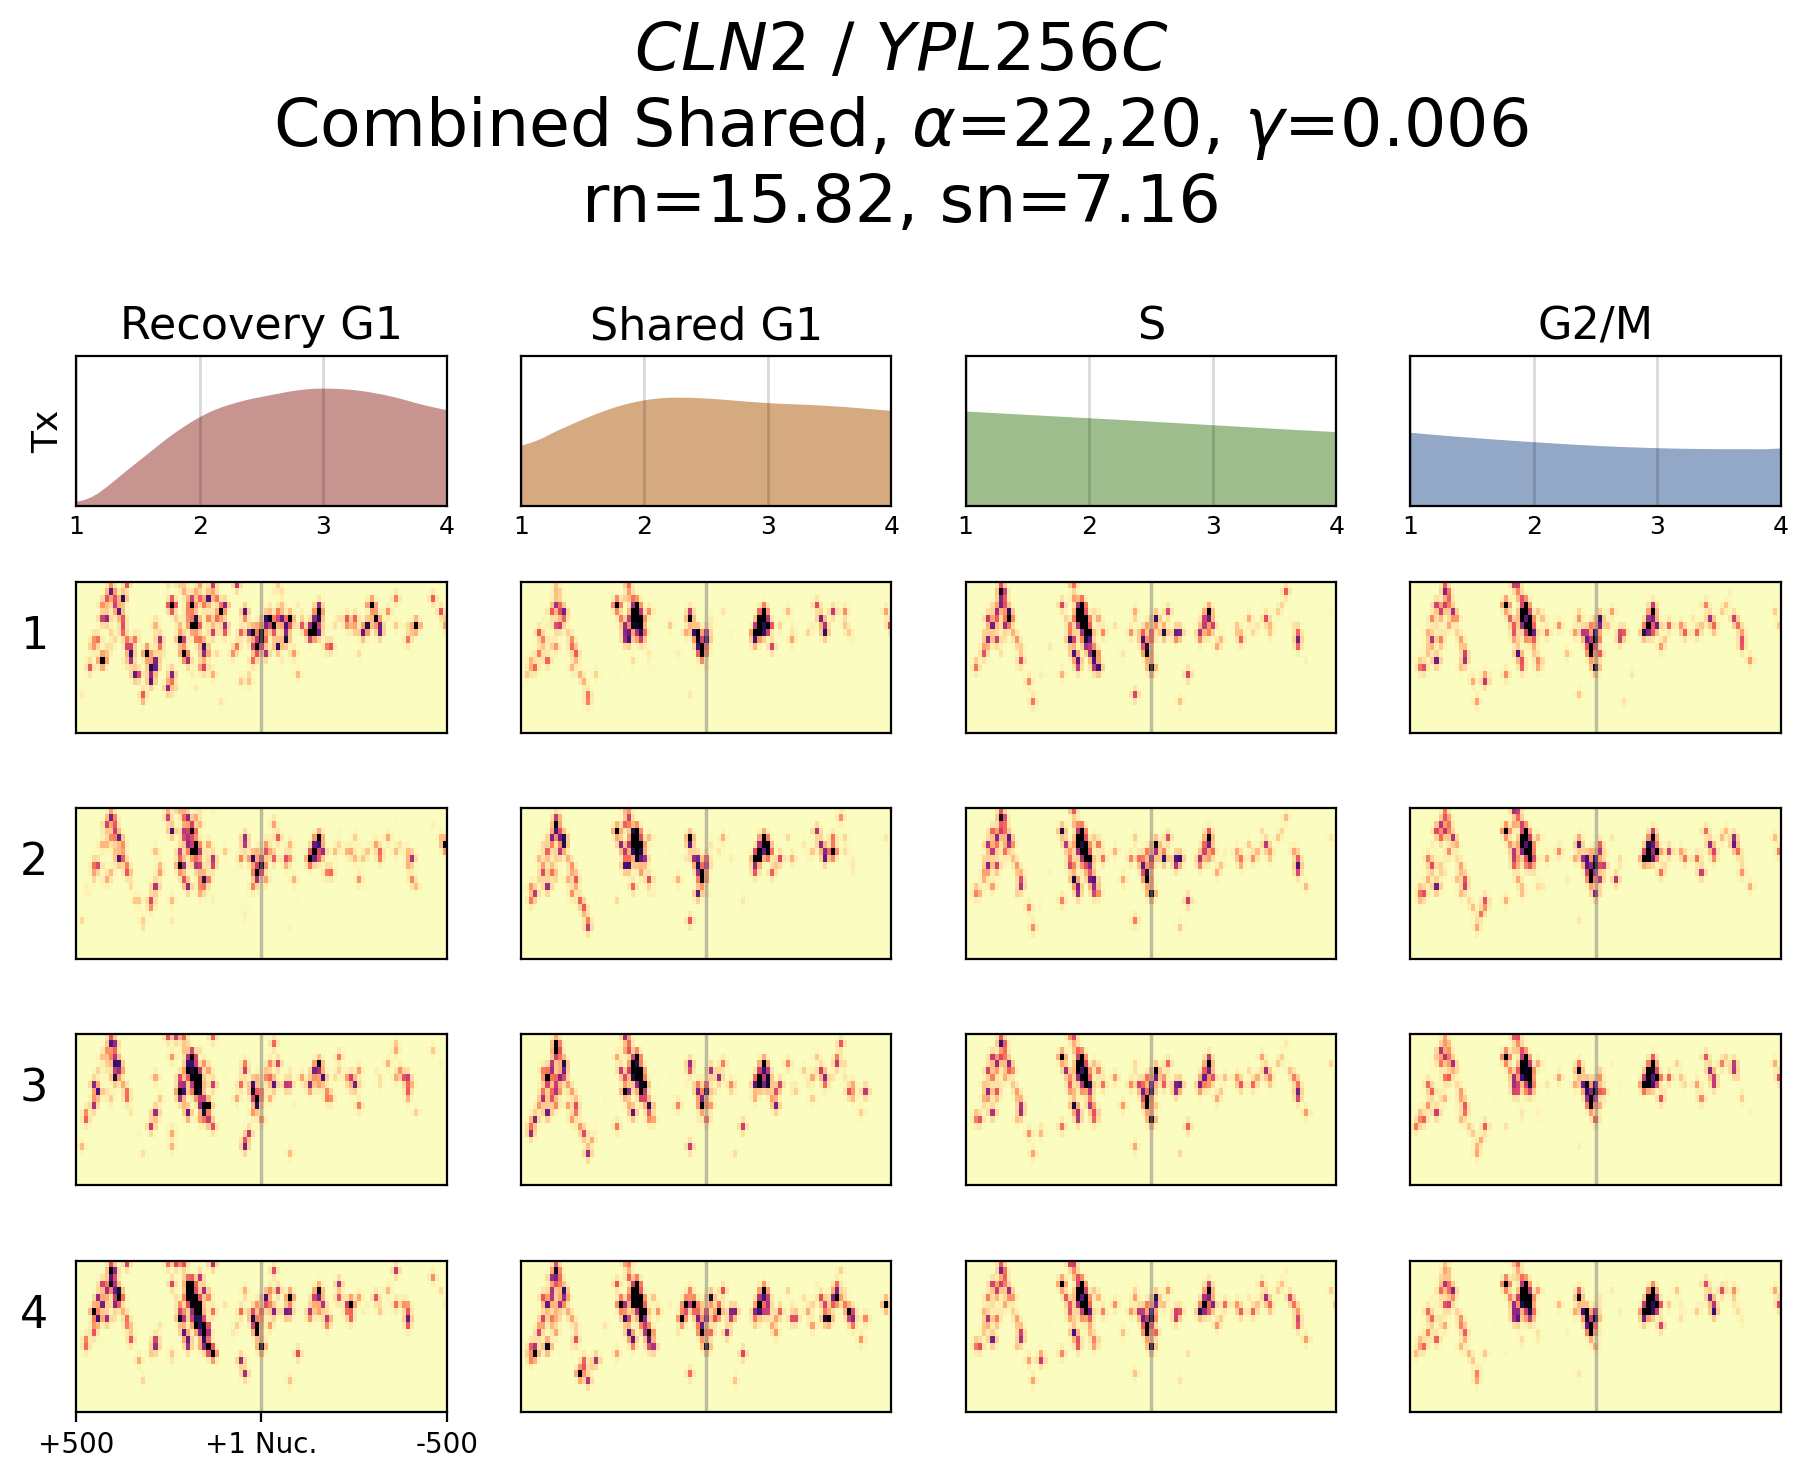

In [109]:
fig1.plot_deconvolution()
save_figure_for_paper('output/figures/Deconvolution_Example.png')

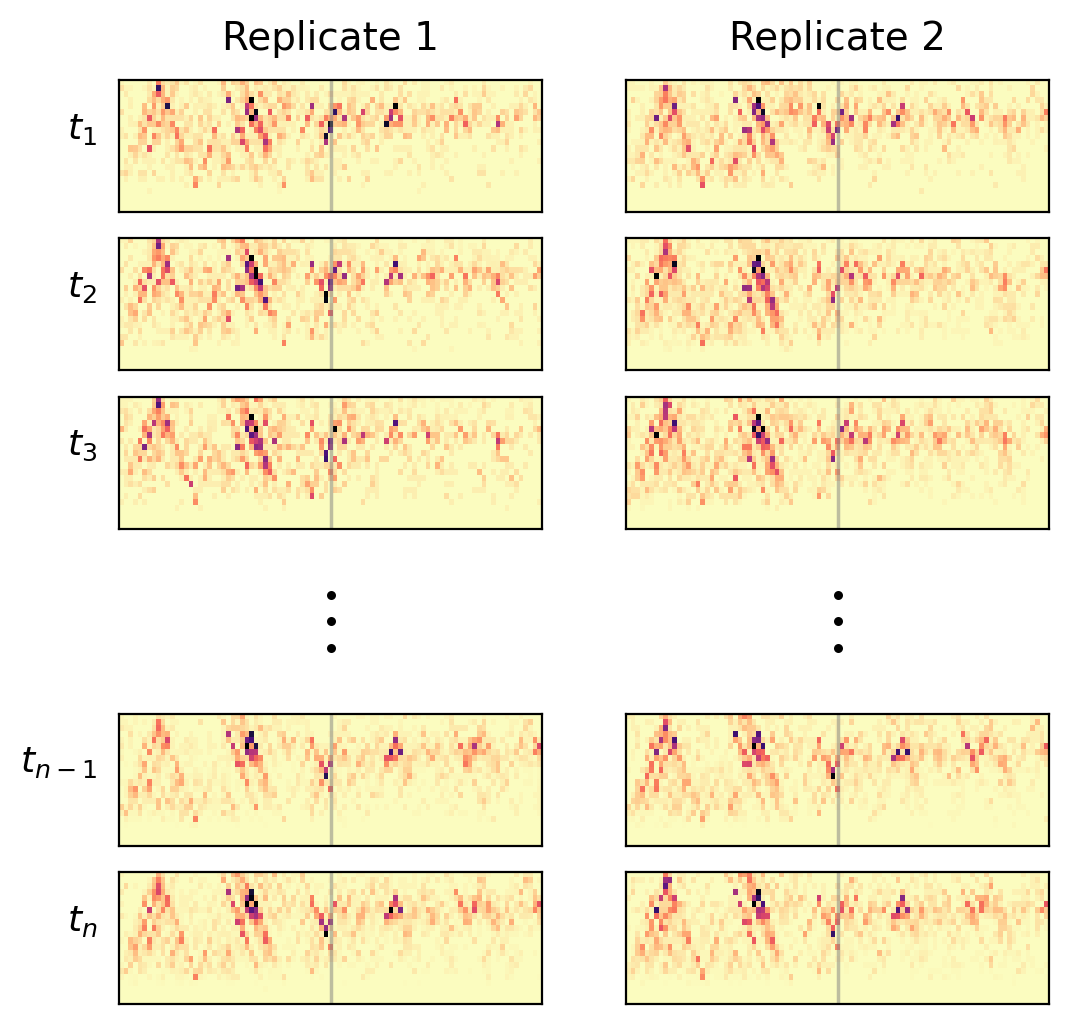

In [110]:
from src.figure_configs import save_figure_for_paper

fig1.plot_raw_example()
save_figure_for_paper('output/figures/Chromatin_Deconvolution/Deconvolution_raw.png')

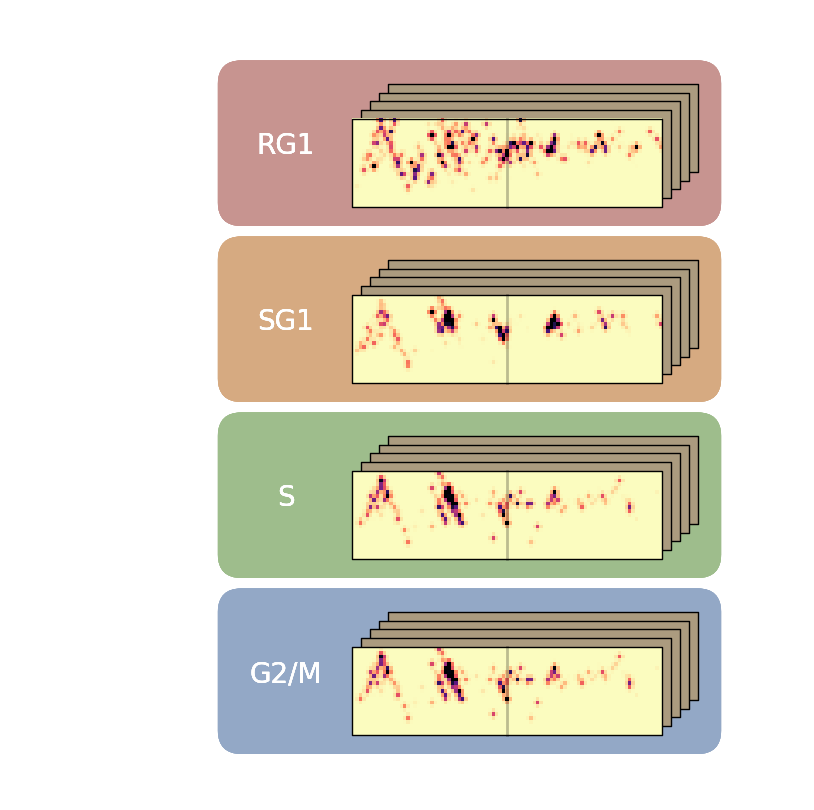

In [111]:
fig1.plot_deconvolved_phase_annotated()
save_figure_for_paper('output/figures/Chromatin_Deconvolution/Deconvolved_phases.png')

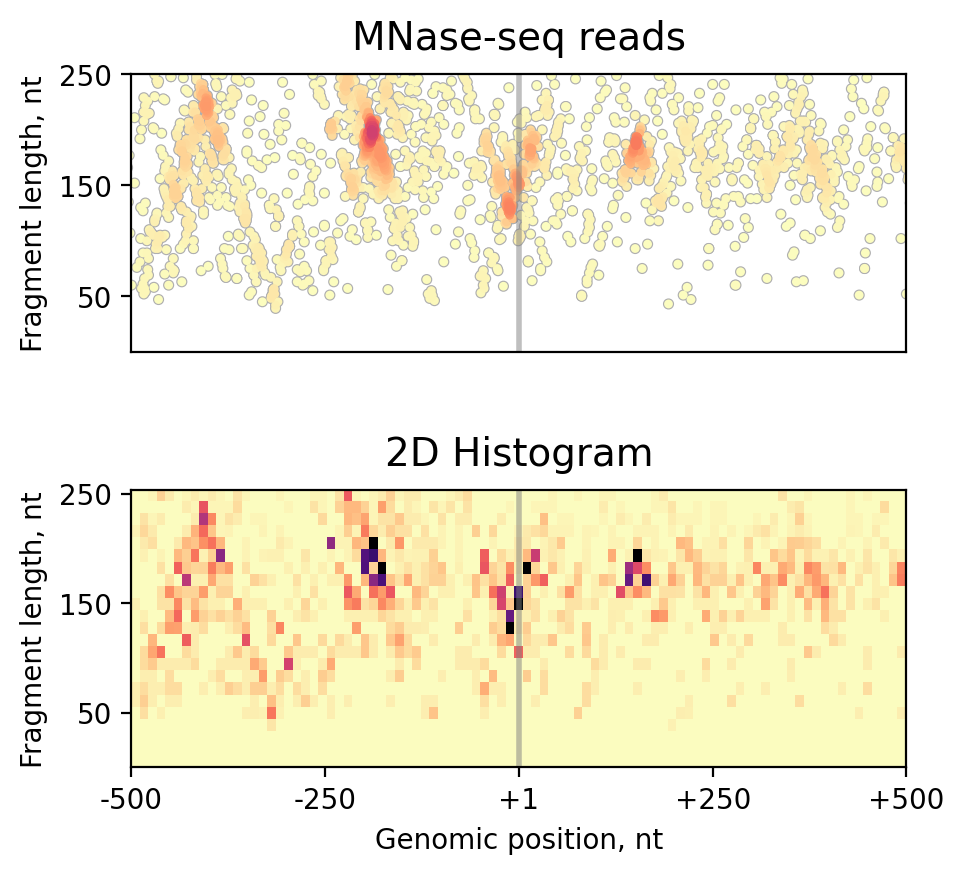

In [112]:
fig1.plot_mnase_reads_histogram()
save_figure_for_paper('output/figures/Chromatin_Deconvolution/MNase_Reads_2D.png')

In [246]:
from src.config import load_configs_by_config_type, \
    load_combined_gene_expression_by_config_type
from src.model import Model
from src.combined_chromatin_model import CombinedChromatinModel
from src.geneset import cyclin_genes

gene_name = 'CLB6'

config1, config2 = load_configs_by_config_type('shared')
combined_ge_config = load_combined_gene_expression_by_config_type('shared')

combined_ge_model = Model(combined_ge_config, gene_name)
combined_ge_model.deconvolve_find_optimal_gamma()
combined_model = CombinedChromatinModel(config1, config2)

combined_model.load_combined_mnase_gene(gene_name)
combined_model.gamma = 0.0066

Loading MNase reads for YGR109C/CLB6...Loading chromosome reads: 7
Done.
Applying chromatin copy number correction
Copy correction vector does not exist, using no correction. gene: CLB6, chr: 7, 706581
Loading MNase reads for YGR109C/CLB6...Loading chromosome reads: 7
Done.
Applying chromatin copy number correction
Copy correction vector does not exist, using no correction. gene: CLB6, chr: 7, 706581


In [247]:
combined_model.deconvolve()

Deconvolving combined model with gamma=0.006
Deconvolving bin size: 11x11
of G shape: (31, 2093)
Deconvolving with gamma=0.006
0/2093 - 00:00:00.086
500/2093 - 00:00:35.843
1000/2093 - 00:01:06.928
1500/2093 - 00:01:38.096
2000/2093 - 00:02:11.182
Deconvolved in : 00:02:17.882
The fitting norm is 14.21, the smoothing norm is: 5.91


There are 118 MacIsaac TFs
There are 49 cell cycle transcription factors (CCTFs) profiled by Kelliher, 2018
There are 340 transcription factors profiled using ChIP-exo by Rossi, 2021
There are 17 CCTFS in the Rossi dataset.
There are 22 CCTFS in the MacIsaac dataset.


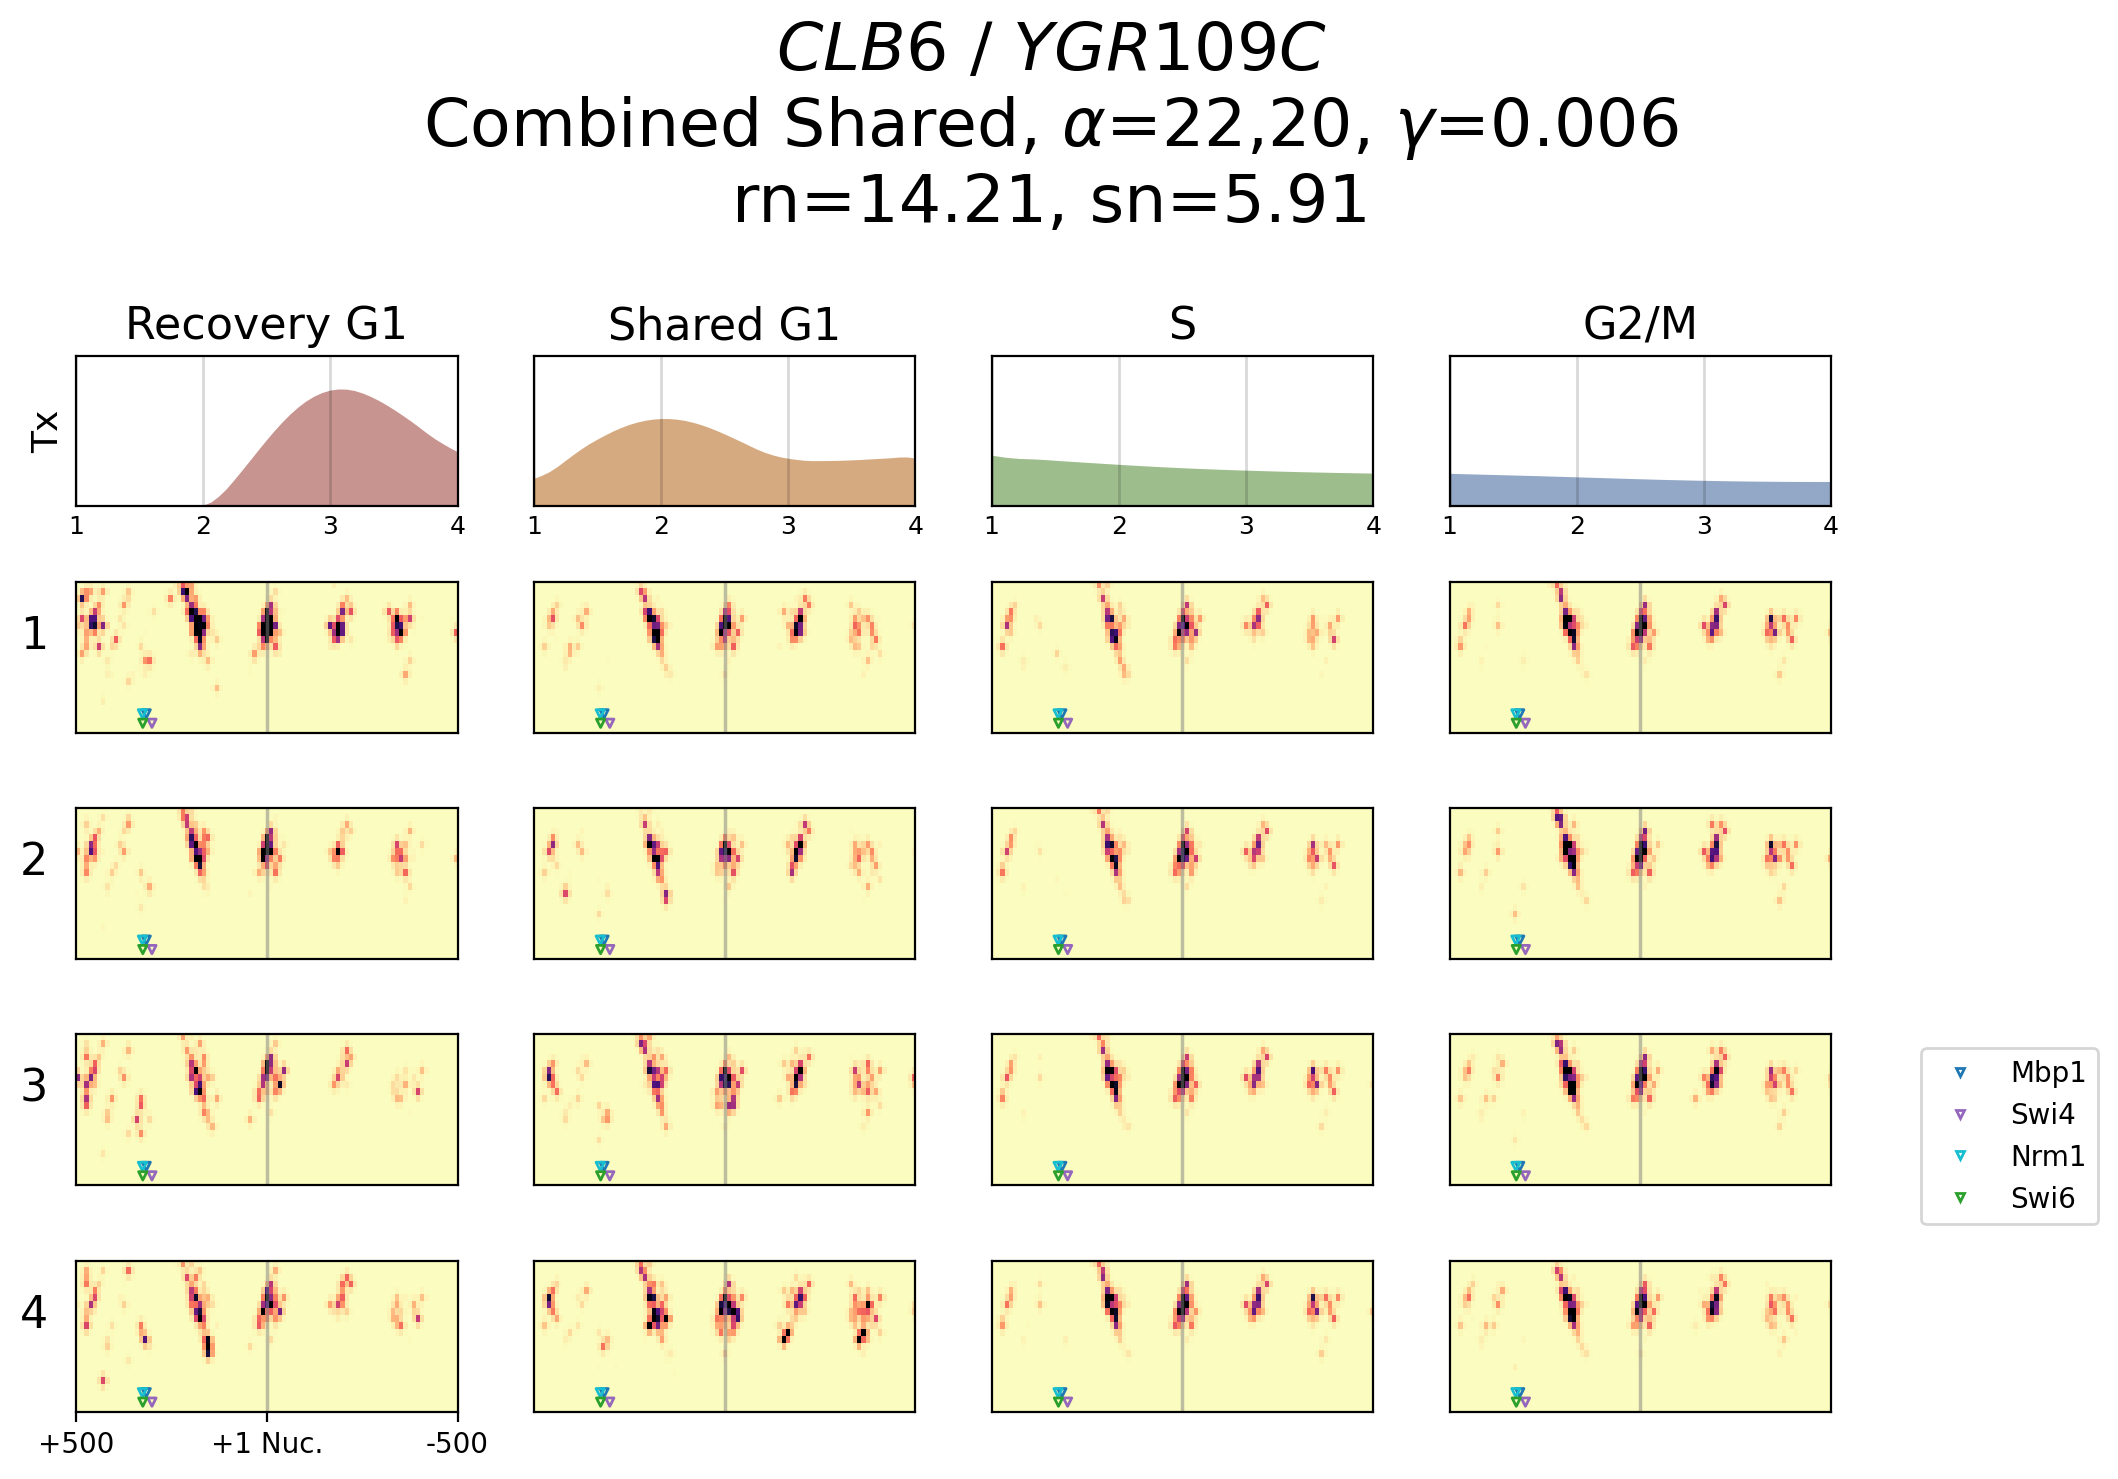

In [255]:
from src.figure_configs import save_figure_for_paper

fig = combined_model.create_deconvolution_plots_abbreviated_flipped(vmax=16, 
    ge_model=combined_ge_model, should_smooth_data=True)
save_figure_for_paper(f'output/figures/Cyclins_Story/{gene_name}_w_motifs.png')

In [475]:
gene_name = 'CLB2'

config1, config2 = load_configs_by_config_type('shared')
combined_ge_config = load_combined_gene_expression_by_config_type('shared')

combined_ge_model = Model(combined_ge_config, gene_name)
combined_ge_model.deconvolve_find_optimal_gamma()
combined_model = CombinedChromatinModel(config1, config2)

combined_model.load_combined_mnase_gene(gene_name)
combined_model.gamma = 0.0066

# Temporarily doubling the deconvolution window to check for
# occupancy normalization....

print("*** TODO: Tripling promoter and gene body nucleosome length **")


Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.
Applying chromatin copy number correction
Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.
Applying chromatin copy number correction
*** TODO: Tripling promoter and gene body nucleosome length **


In [476]:
combined_model.deconvolve()

Deconvolving combined model with gamma=0.006
Deconvolving bin size: 11x11
of G shape: (31, 6233)
Deconvolving with gamma=0.006
0/6233 - 00:00:00.095
500/6233 - 00:00:37.027
1000/6233 - 00:01:12.546
1500/6233 - 00:01:44.786
2000/6233 - 00:02:16.627
2500/6233 - 00:02:47.779
3000/6233 - 00:03:18.617
3500/6233 - 00:03:49.225
4000/6233 - 00:04:19.506
4500/6233 - 00:04:50.321
5000/6233 - 00:05:20.873
5500/6233 - 00:05:51.009
6000/6233 - 00:06:21.127
Deconvolved in : 00:06:35.982
The fitting norm is 15.67, the smoothing norm is: 4.91


There are 118 MacIsaac TFs
There are 49 cell cycle transcription factors (CCTFs) profiled by Kelliher, 2018
There are 340 transcription factors profiled using ChIP-exo by Rossi, 2021
There are 17 CCTFS in the Rossi dataset.
There are 22 CCTFS in the MacIsaac dataset.
*** Window is large enough to try and normalize each f image to the same sum
6


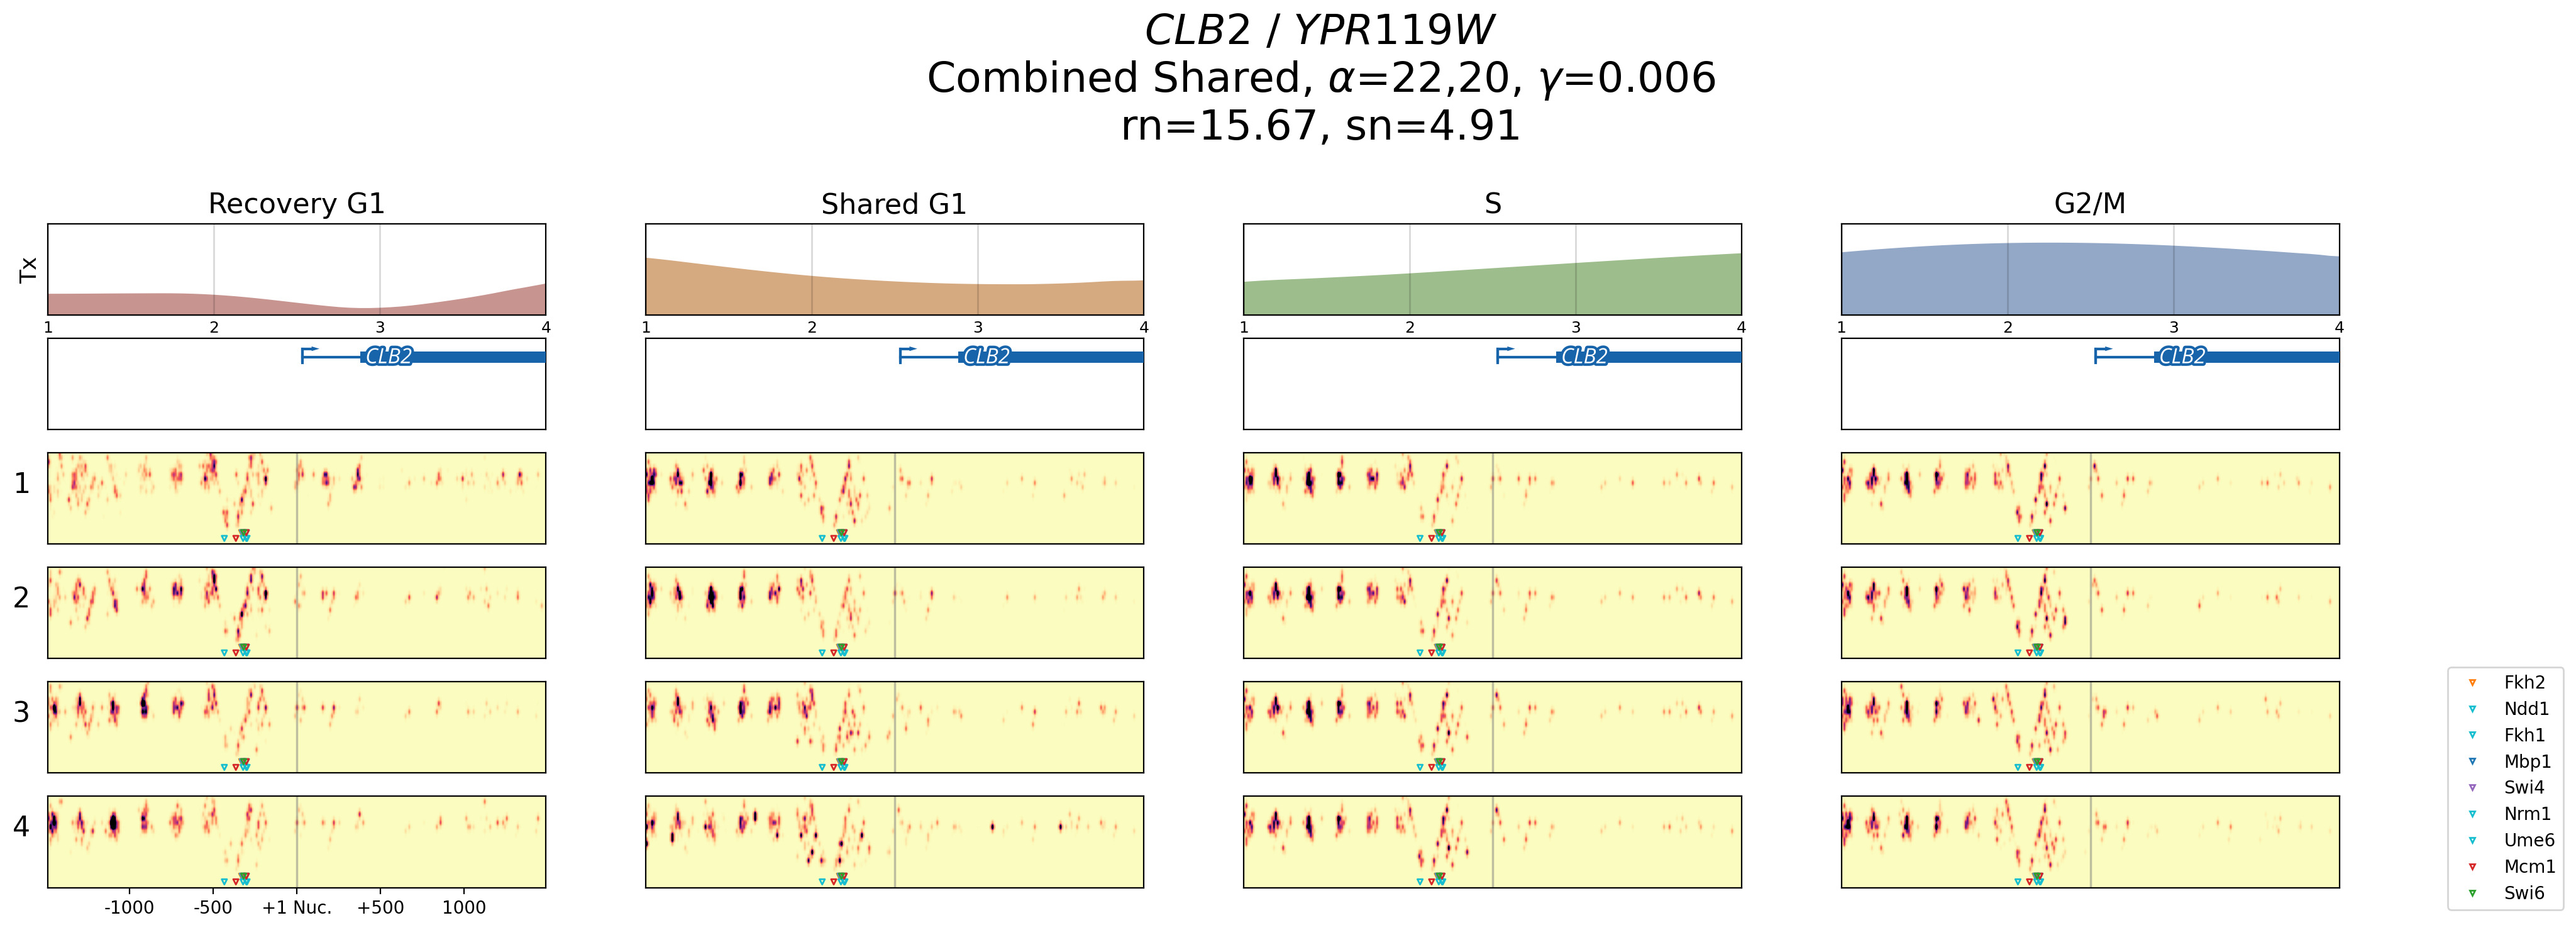

In [477]:
fig = combined_model.create_deconvolution_plots_abbreviated_flipped(vmax=10, 
    ge_model=combined_ge_model, should_smooth_data=True, normalized_f=True)

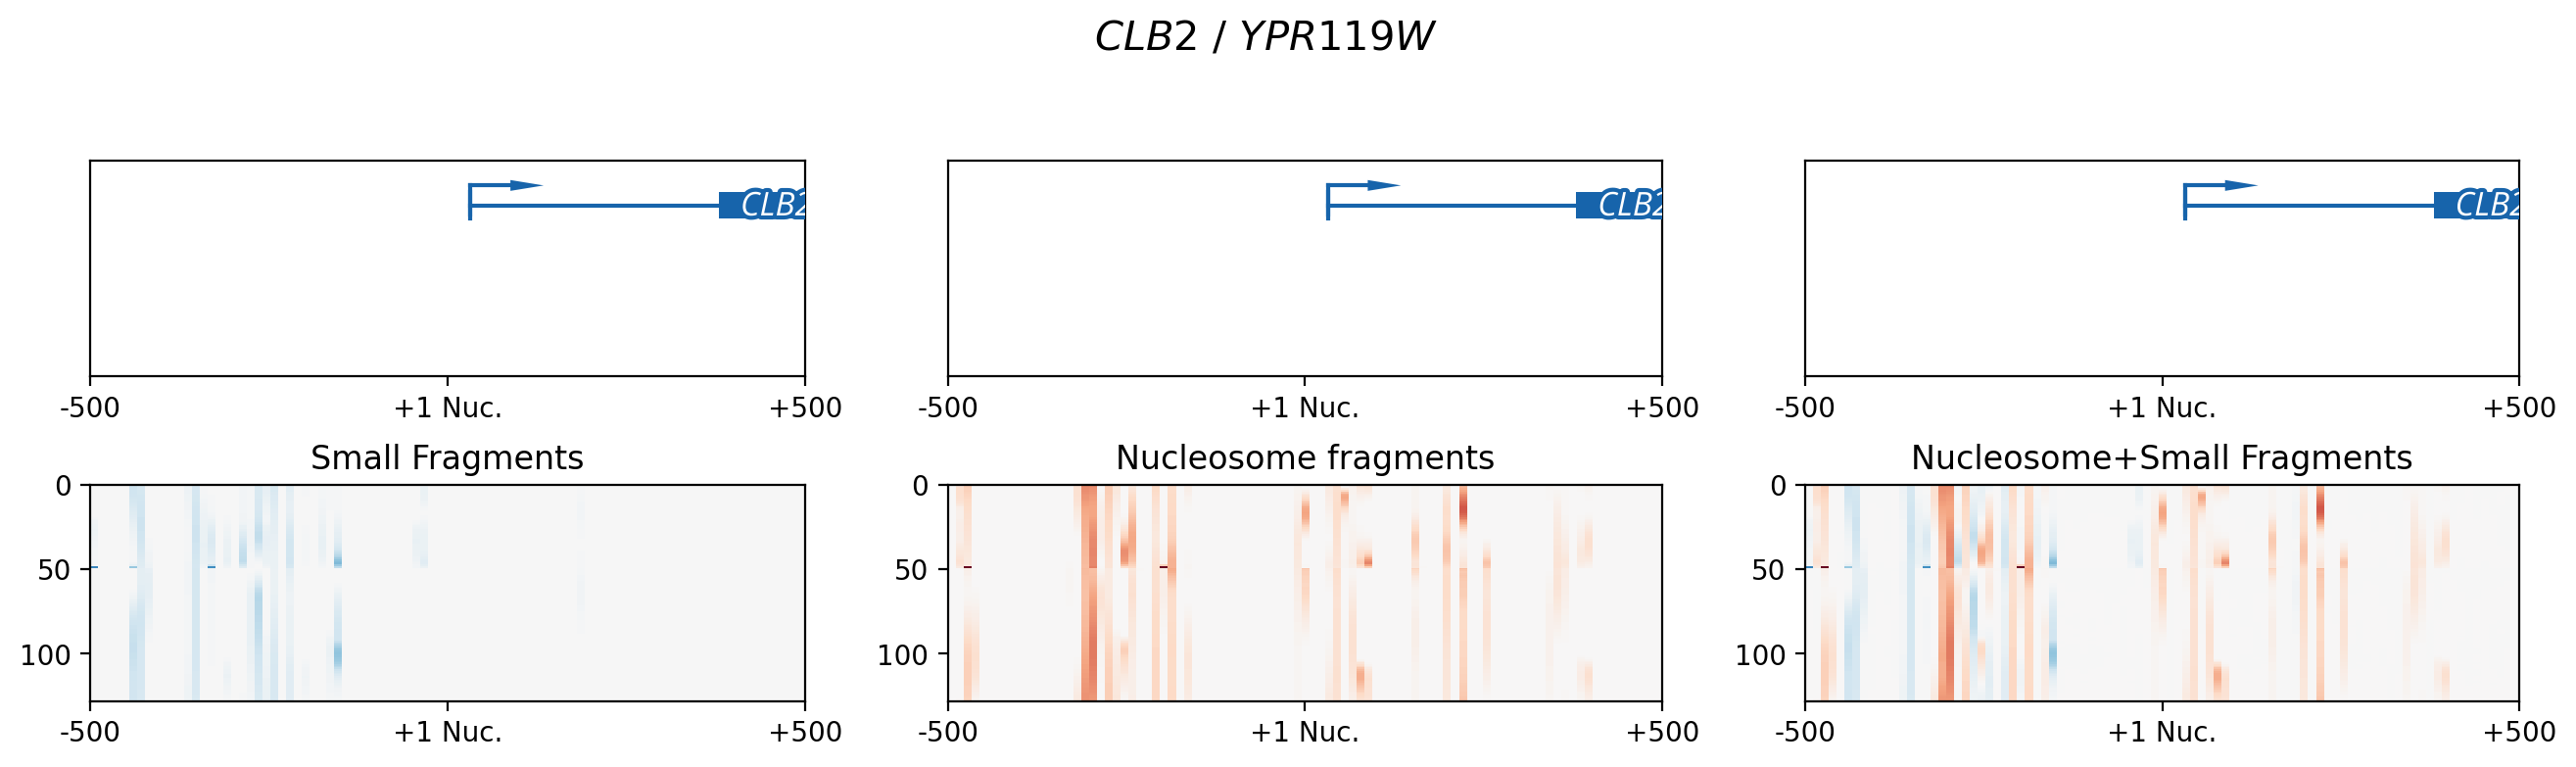

In [478]:
combined_model.plot_sm_nuc_hm()
save_figure_for_paper(f'output/figures/Cyclins_Story/{gene_name}_heatmap.png')

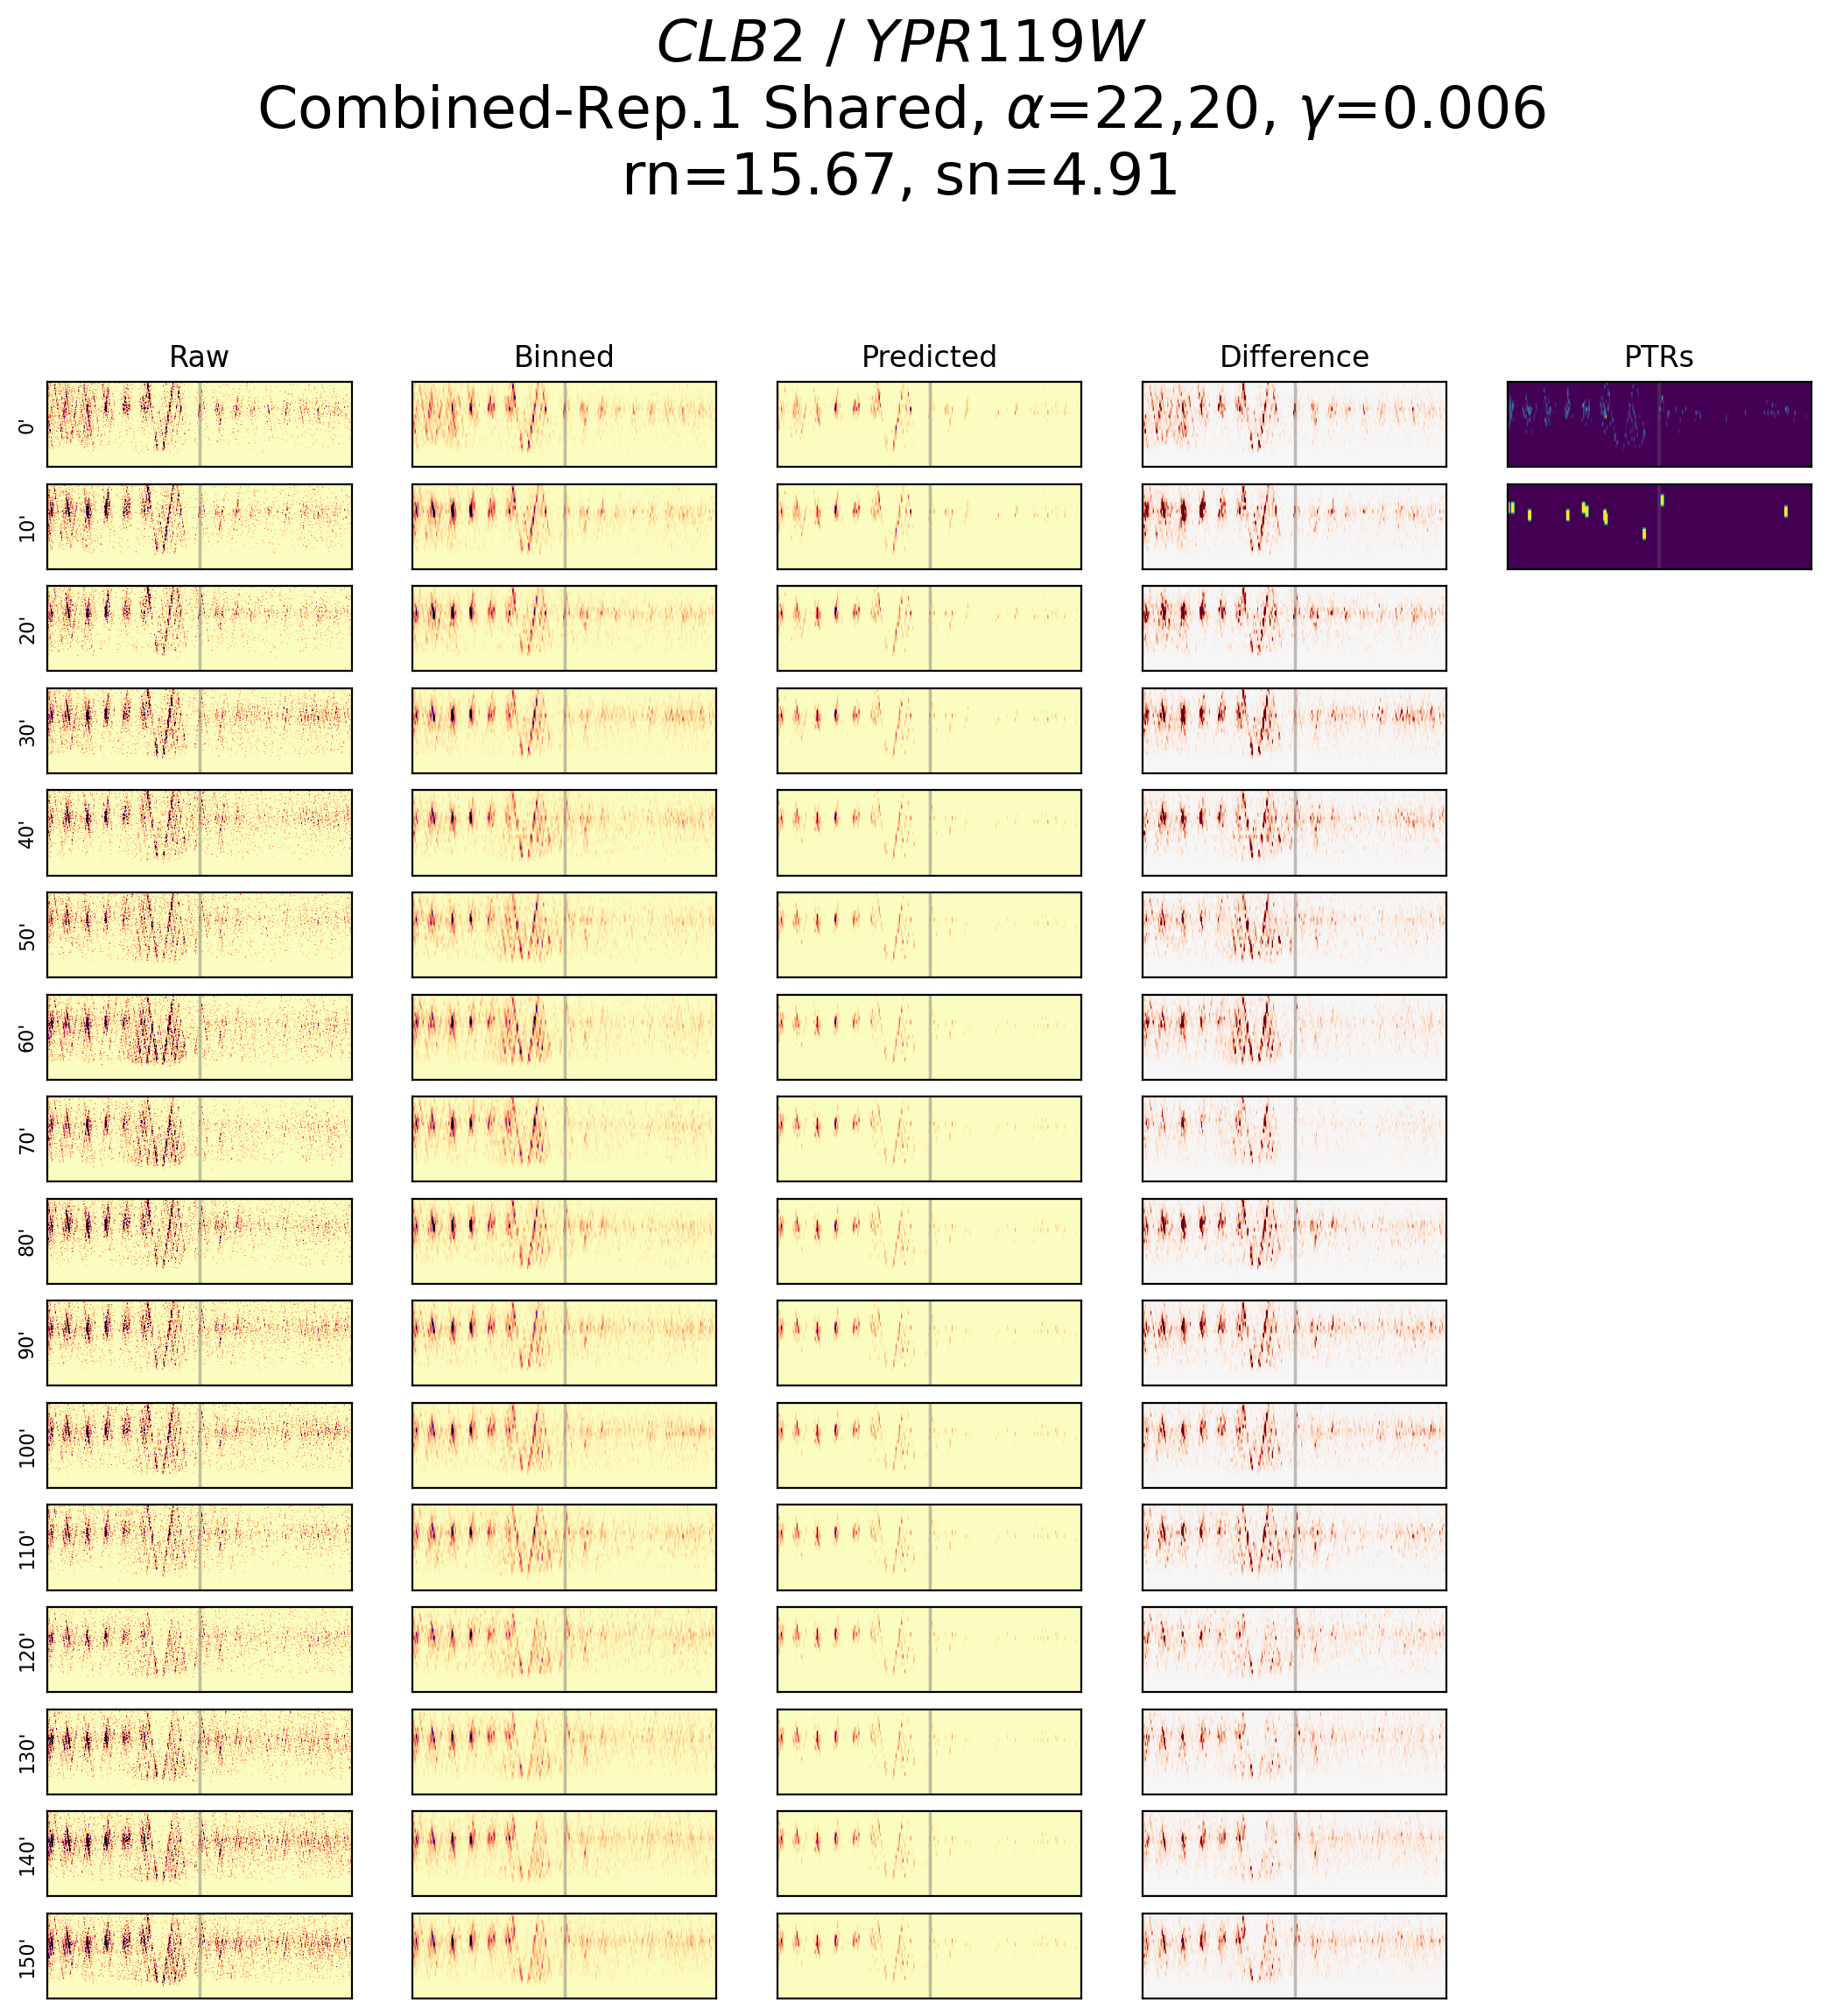

In [480]:
fig = combined_model.plot_raw_prediction(1)